In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('hotel_bookings.csv', na_values=['NULL', 'NaN'])

# Duplikaty
initial_len = len(df)
df_clean = df.drop_duplicates().copy()
print(f'Usunięto {initial_len - len(df_clean)} duplikatów.')

# Uzupełnienie braków
df_clean['children'] = df_clean['children'].fillna(0)
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Drop company (zbyt dużo braków)
df_clean.drop(columns=['company'], inplace=True, errors='ignore')

# Filtry sanity check
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 1000)]
df_clean = df_clean[(df_clean['adults'] + df_clean['children'] + df_clean['babies']) > 0]

# Usunięcie wycieków danych
leaked_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
df_clean.drop(columns=leaked_cols, inplace=True, errors='ignore')

print(f'Po czyszczeniu: {len(df_clean)} wierszy, {df_clean.isnull().sum().sum()} braków.')

Usunięto 31994 duplikatów.
Po czyszczeniu: 87228 wierszy, 0 braków.


In [3]:
# Miesiąc -> liczba (zachowuje chronologię)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12,
}
df_clean['arrival_date_month'] = df_clean['arrival_date_month'].map(month_map)

# Inżynieria cech
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']

# Country -> drop (high cardinality, słabe sygnały po groupingu)
if 'country' in df_clean.columns:
    df_clean = df_clean.drop(columns=['country'])

# Ordinal encoding
cols_to_encode = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
]
encoder = OrdinalEncoder()
df_clean[cols_to_encode] = encoder.fit_transform(df_clean[cols_to_encode])

# X / y / split
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']
# Uwaga: bez stratify=y dla spójności z ML_tree_max_dep_loop.ipynb.
# Stratify=y byłby drobnym ulepszeniem metodologicznym (gwarantuje ten sam
# balans klas w train/test) — możesz dodać jeśli chcesz świadomej zmiany.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Balans klas w y_train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Balans klas w y_train: {y_test.value_counts(normalize=True).round(3).to_dict()}')

X_train: (69782, 28) | X_test: (17446, 28)
Balans klas w y_train: {0: 0.724, 1: 0.276}
Balans klas w y_train: {0: 0.728, 1: 0.272}


In [4]:
# ── KONFIGURACJA ──────────────────────────────────────────────────────────
VIZ_DEPTH = 4              # model do wizualizacji (czytelny)
BEST_DEPTH = 12            # model produkcyjny (najlepszy rozsądny)
BEST_CCP_ALPHA = 0.000061  # ccp_alpha wygrywający na test set dla depth=12
RANDOM_STATE = 12345       # spójne z głównym notebookiem
CLASS_NAMES = ['Not Canceled', 'Canceled']
FEATURE_NAMES = X.columns.tolist()
# ──────────────────────────────────────────────────────────────────────────

viz_model = DecisionTreeClassifier(
    max_depth=VIZ_DEPTH,
    random_state=RANDOM_STATE,
)
viz_model.fit(X_train, y_train)

best_model = DecisionTreeClassifier(
    max_depth=BEST_DEPTH,
    ccp_alpha=BEST_CCP_ALPHA,
    random_state=RANDOM_STATE,
)
best_model.fit(X_train, y_train)

def quick_summary(name, m):
    pred = m.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f'{name:30s} depth={m.get_depth():2d} | leaves={m.get_n_leaves():5d} | acc={acc*100:5.2f}% | F1={f1*100:5.2f}%')

quick_summary('Model interpretowalny', viz_model)
quick_summary('Model produkcyjny', best_model)

Model interpretowalny          depth= 4 | leaves=   15 | acc=78.40% | F1=52.27%
Model produkcyjny              depth=12 | leaves=  167 | acc=81.07% | F1=57.17%


In [6]:
# Wariant druku: graphviz — najczystszy wygląd do druku/PDF
try:
    import graphviz
    dot_data = export_graphviz(
        viz_model,
        out_file=None,
        feature_names=FEATURE_NAMES,
        class_names=CLASS_NAMES,
        filled=True,
        rounded=True,
        special_characters=True,
        proportion=True,
        impurity=False,
    )
    graph = graphviz.Source(dot_data)
    graph.render('viz_tree_graphviz', format='png', cleanup=True)
    graph.render('viz_tree_graphviz', format='svg', cleanup=True)
    print('Zapisano: viz_tree_graphviz.png + viz_tree_graphviz.svg')
    graph  # wyświetli w notebooku
except ImportError:
    print('graphviz nie zainstalowany. Zainstaluj: pip install graphviz')
    print('Plus binarka systemowa: https://graphviz.org/download/')
except Exception as e:
    print(f'Błąd graphviz: {e}')


Zapisano: viz_tree_graphviz.png + viz_tree_graphviz.svg


## 4. Szczegółowa statystyka modelu produkcyjnego (`max_depth=12`)

Pełna ewaluacja na zbiorze testowym — gotowa do tabeli porównawczej w prezentacji.

In [8]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy':           accuracy_score(y_test, y_pred),
    'Precision':          precision_score(y_test, y_pred),
    'Recall':             recall_score(y_test, y_pred),
    'F1':                 f1_score(y_test, y_pred),
    'F1 (macro avg)':     f1_score(y_test, y_pred, average='macro'),
    'F1 (weighted avg)':  f1_score(y_test, y_pred, average='weighted'),
    'ROC AUC':            roc_auc_score(y_test, y_proba),
}

metrics_df = pd.DataFrame(
    [(k, f'{v*100:.2f}%' if k != 'ROC AUC' else f'{v:.4f}') for k, v in metrics.items()],
    columns=['Metryka', 'Wartość'],
)
metrics_df

,Metryka,Wartość
0,Accuracy,81.07%
1,Precision,74.36%
2,Recall,46.43%
3,F1,57.17%
4,F1 (macro avg),72.51%
5,F1 (weighted avg),79.50%
6,ROC AUC,0.8353


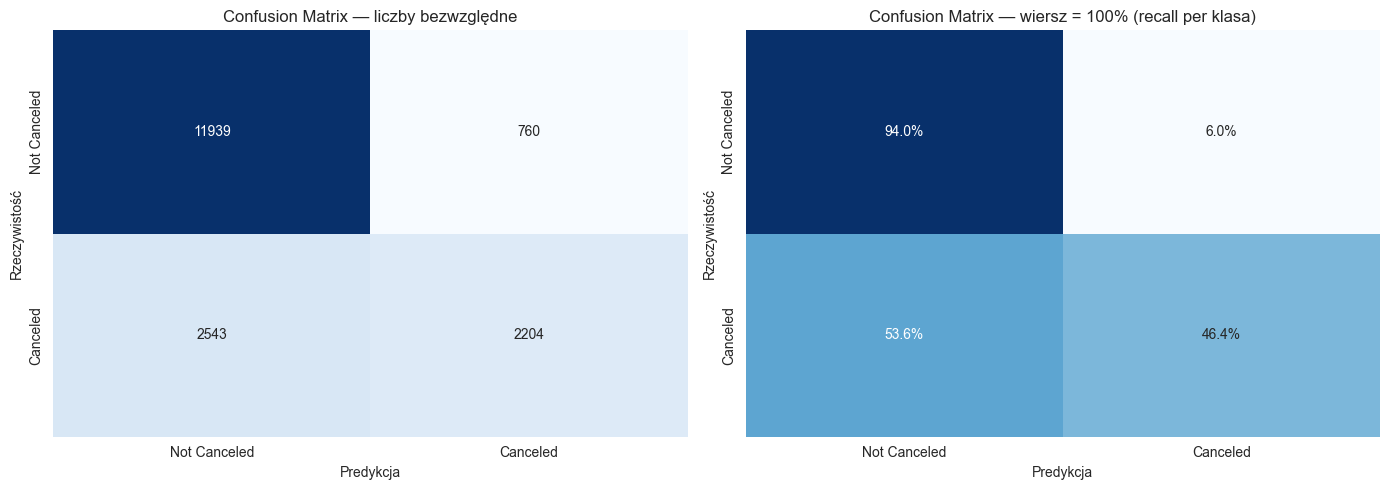

In [9]:
# Confusion matrix — liczbowo i procentowo
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
)
axes[0].set_title('Confusion Matrix — liczby bezwzględne')
axes[0].set_xlabel('Predykcja'); axes[0].set_ylabel('Rzeczywistość')

sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Blues', cbar=False,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
)
axes[1].set_title('Confusion Matrix — wiersz = 100% (recall per klasa)')
axes[1].set_xlabel('Predykcja'); axes[1].set_ylabel('Rzeczywistość')

plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

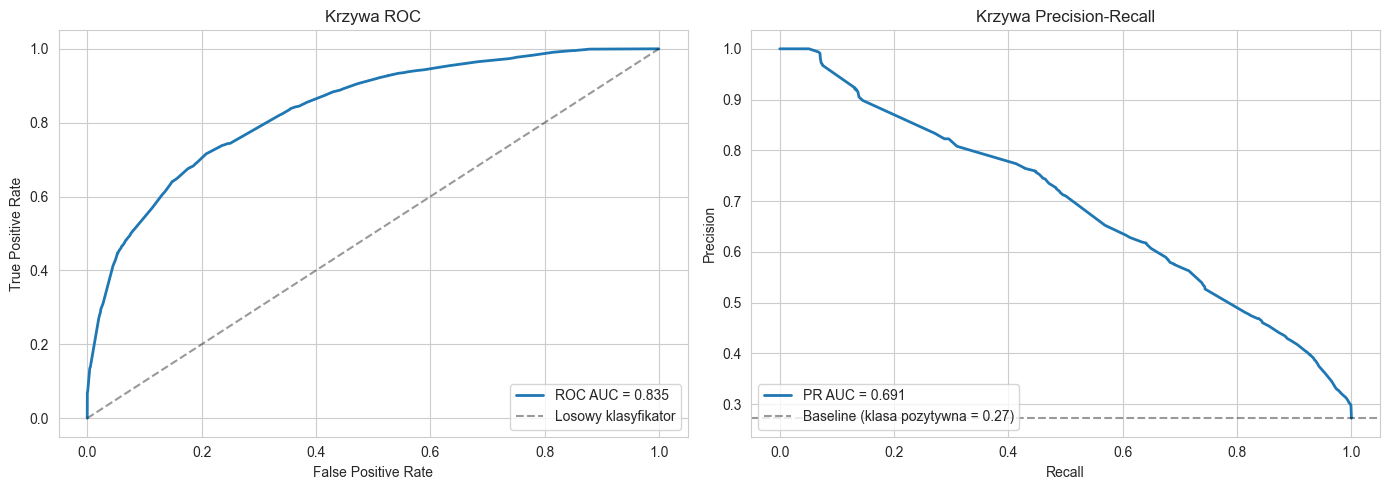

In [10]:
# ROC i Precision-Recall obok siebie
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
baseline = y_test.mean()  # frakcja klasy pozytywnej

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, linewidth=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Losowy klasyfikator')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Krzywa ROC'); axes[0].legend(loc='lower right')

axes[1].plot(recall, precision, linewidth=2, label=f'PR AUC = {pr_auc:.3f}')
axes[1].axhline(y=baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline (klasa pozytywna = {baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Krzywa Precision-Recall'); axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('best_model_roc_pr.png', dpi=200, bbox_inches='tight')
plt.show()

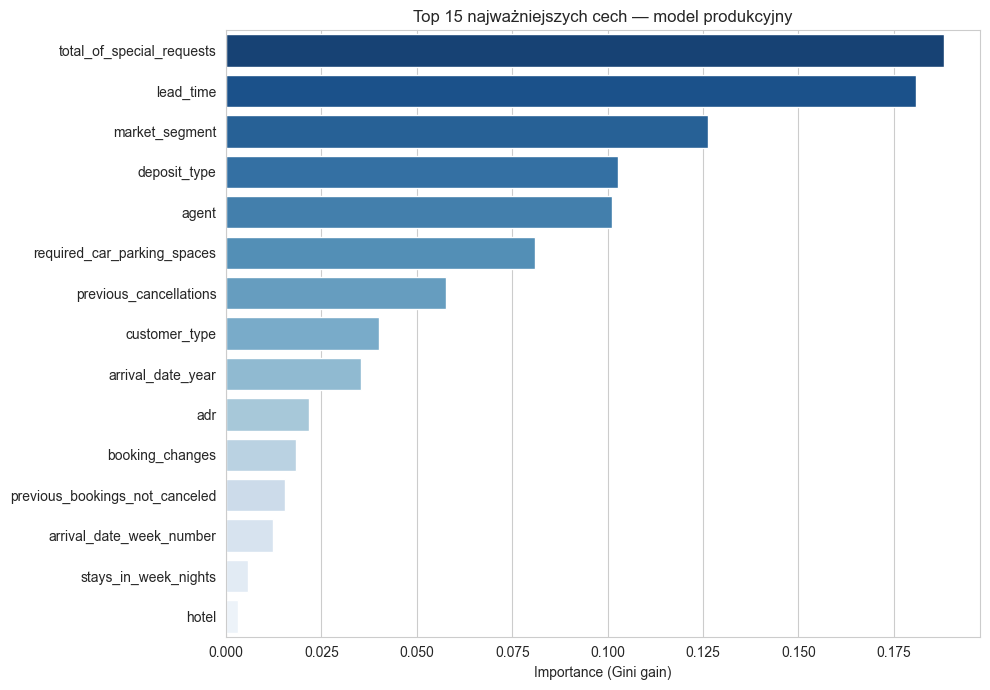

Pełna lista feature importance:


,feature,importance
0,total_of_special_requests,0.188224
1,lead_time,0.180817
2,market_segment,0.126314
3,deposit_type,0.102861
4,agent,0.101258
5,required_car_parking_spaces,0.080908
6,previous_cancellations,0.057675
7,customer_type,0.040061
8,arrival_date_year,0.035272
9,adr,0.021635


In [11]:
# Feature importance — top 15
feat_imp = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

top_n = 15
feat_imp_top = feat_imp.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feat_imp_top, y='feature', x='importance',
    palette='Blues_r', hue='feature', legend=False,
)
plt.title(f'Top {top_n} najważniejszych cech — model produkcyjny')
plt.xlabel('Importance (Gini gain)'); plt.ylabel('')
plt.tight_layout()
plt.savefig('best_model_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

print('Pełna lista feature importance:')
feat_imp.reset_index(drop=True)

In [12]:
# Classification report — per-klasa precision/recall/F1
report = classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES, digits=4,
)
print(report)

# Wersja DataFrame (wygodniejsza do wstawienia do prezentacji)
report_dict = classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES, digits=4, output_dict=True,
)
pd.DataFrame(report_dict).T.round(4)

              precision    recall  f1-score   support

Not Canceled     0.8244    0.9402    0.8785     12699
    Canceled     0.7436    0.4643    0.5717      4747

    accuracy                         0.8107     17446
   macro avg     0.7840    0.7022    0.7251     17446
weighted avg     0.8024    0.8107    0.7950     17446



,precision,recall,f1-score,support
Not Canceled,0.8244,0.9402,0.8785,12699.0000
Canceled,0.7436,0.4643,0.5717,4747.0000
accuracy,0.8107,0.8107,0.8107,0.8107
macro avg,0.7840,0.7022,0.7251,17446.0000
weighted avg,0.8024,0.8107,0.7950,17446.0000


## 5. Podsumowanie porównawcze

Tabela do prezentacji — kompromis interpretowalność vs. dokładność.

In [13]:
def model_row(name, m, purpose):
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Cel': purpose,
        'max_depth': m.get_depth(),
        'Liczba liści': m.get_n_leaves(),
        'Accuracy': f'{accuracy_score(y_test, pred)*100:.2f}%',
        'F1': f'{f1_score(y_test, pred)*100:.2f}%',
        'Precision': f'{precision_score(y_test, pred)*100:.2f}%',
        'Recall': f'{recall_score(y_test, pred)*100:.2f}%',
        'ROC AUC': f'{roc_auc_score(y_test, proba):.3f}',
    }

summary = pd.DataFrame([
    model_row('Interpretowalny', viz_model, 'Wizualizacja / wytłumaczalność'),
    model_row('Produkcyjny',     best_model, 'Najlepsza predykcja (single tree)'),
]).set_index('Model').T

summary

Model,Interpretowalny,Produkcyjny
Cel,Wizualizacja / wytłumaczalność,Najlepsza predykcja (single tree)
max_depth,4,12
Liczba liści,15,167
Accuracy,78.40%,81.07%
F1,52.27%,57.17%
Precision,65.55%,74.36%
Recall,43.46%,46.43%
ROC AUC,0.771,0.835
